# Criterion 5 — Model Evaluation, Visualisation & Reporting

This notebook brings together all models from C2, C3 and C4 and performs a unified performance evaluation. The goal is to go beyond just printing metrics, I want to understand why each model performs the way it does, identify where they fail, and suggest concrete improvements.

The analysis follows four stages:

1. Re-load all trained models and the shared dataset
2. Classification evaluation — metrics, confusion matrices, misclassification analysis
3. Regression evaluation — error analysis, residual diagnostics, model comparison
4. Clustering evaluation — internal validation, cross-algorithm comparison
5. Visualisation & reporting — summary charts, insights dashboard

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve, silhouette_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

import os
os.makedirs("../results", exist_ok=True)

# Load the engineered dataset (output of C1 → C2 pipeline)
df = pd.read_csv("../data/Engineered_Traffic_Data.csv", low_memory=False)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 7933 rows, 54 columns


## 2. Rebuild Feature Sets

I'm rebuilding the exact same feature sets and splits used in C2 and C3 so the evaluation metrics here are directly comparable to those reported in the earlier notebooks. Using the same random_state=42 throughout ensures reproducibility.

In [2]:
FEATURES_A = ["weather_conditions_enc", "road_type_enc", "light_conditions",
              "speed_limit", "number_of_vehicles", "road_surface_conditions_enc",
              "junction_detail_enc", "junction_control_enc", "urban_or_rural_area_enc",
              "day_of_week", "hour", "is_weekend", "time_of_day_bin", "is_dark"]

X_clf = df[FEATURES_A]
y_clf = df["collision_severity"]   # 1=Fatal, 2=Serious, 3=Slight

# 60/15/25 split — same as C2
X_tv, X_test, y_tv, y_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, random_state=42, stratify=y_tv)

# SMOTE on training only — same as C2
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Regression target and features
REG_FEATURES = ["weather_conditions_enc", "light_conditions",
                "road_surface_conditions_enc", "junction_detail_enc",
                "junction_control_enc", "speed_limit", "urban_or_rural_area_enc",
                "day_of_week", "hour", "is_weekend", "number_of_vehicles",
                "road_type_enc", "time_of_day_bin", "is_dark"]

X_reg = df[REG_FEATURES]
y_reg = df["number_of_casualties"]

Xr_tv, Xr_test, yr_tv, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42)
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    Xr_tv, yr_tv, test_size=0.20, random_state=42)

print("Classification splits:")
print(f"  Train: {len(X_train_res)}, Val: {len(X_val)}, Test: {len(X_test)}")
print("Regression splits:")
print(f"  Train: {len(Xr_train)}, Val: {len(Xr_val)}, Test: {len(Xr_test)}")

Classification splits:
  Train: 11790, Val: 1190, Test: 1984
Regression splits:
  Train: 4759, Val: 1190, Test: 1984


## 3. Classification Evaluation

I'll train all classifiers used in C2 here and evaluate them on the test set. One thing to be upfront about before looking at the numbers: this is a heavily imbalanced dataset. *Slight* collisions make up roughly 79% of all records, Serious around 18%, and Fatal only about 1–2%. That imbalance makes accuracy a useless metric here — a model that just predicts *Slight* every time would score ~79% without learning anything useful. So throughout this section I'm using macro F1, which scores each class equally regardless of how common it is.

The consequence of that imbalance is that macro F1 scores are going to look low. That's expected, not a sign something went wrong.

In [3]:
# Train all classifiers on SMOTE-balanced training data
classifiers = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree":        DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)":            KNeighborsClassifier(n_neighbors=5),
    "KNN (k=11)":           KNeighborsClassifier(n_neighbors=11),
    "SVM (RBF)":            SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    "Naive Bayes":          GaussianNB(),
}

label_names = ["Fatal", "Serious", "Slight"]

clf_summary = []
trained_clfs = {}

for name, clf in classifiers.items():
    clf.fit(X_train_res, y_train_res)
    trained_clfs[name] = clf
    y_pred = clf.predict(X_test)
    clf_summary.append({
        "Model":        name,
        "Accuracy":     round(accuracy_score(y_test, y_pred), 4),
        "Macro F1":     round(f1_score(y_test, y_pred, average="macro"), 4),
        "Weighted F1":  round(f1_score(y_test, y_pred, average="weighted"), 4),
        "Fatal F1":     round(f1_score(y_test, y_pred, labels=[1], average="macro"), 4),
        "Serious F1":   round(f1_score(y_test, y_pred, labels=[2], average="macro"), 4),
        "Slight F1":    round(f1_score(y_test, y_pred, labels=[3], average="macro"), 4),
    })

clf_df = pd.DataFrame(clf_summary).set_index("Model").sort_values("Macro F1", ascending=False)
print("=== Classification Model Comparison (Test Set) ===")
print(clf_df.to_string())

=== Classification Model Comparison (Test Set) ===
                     Accuracy  Macro F1  Weighted F1  Fatal F1  Serious F1  Slight F1
Model                                                                                
Gradient Boosting      0.7550    0.3785       0.7435    0.0800      0.1942     0.8613
Decision Tree          0.6845    0.3745       0.7019    0.0984      0.2195     0.8057
Random Forest          0.7555    0.3714       0.7432    0.0426      0.2140     0.8577
SVM (RBF)              0.5439    0.3442       0.6197    0.0480      0.2920     0.6926
Logistic Regression    0.5625    0.3383       0.6287    0.0519      0.2515     0.7114
KNN (k=5)              0.5872    0.3339       0.6413    0.0238      0.2505     0.7273
KNN (k=11)             0.5378    0.3193       0.6055    0.0252      0.2485     0.6843
Naive Bayes            0.4541    0.3009       0.5551    0.0333      0.2457     0.6237


### 3.1 Classifier Summary Bar Chart

The chart below shows macro F1 on the test set for all classifiers. The dashed red line marks 0.80 as a reference point, all models fall well short of it, with the best (Gradient Boosting) sitting around 0.38.

That gap looks alarming but it's explained by the class imbalance. The Fatal class has so few real examples that even after SMOTE, classifiers struggle to learn reliable decision boundaries for it.

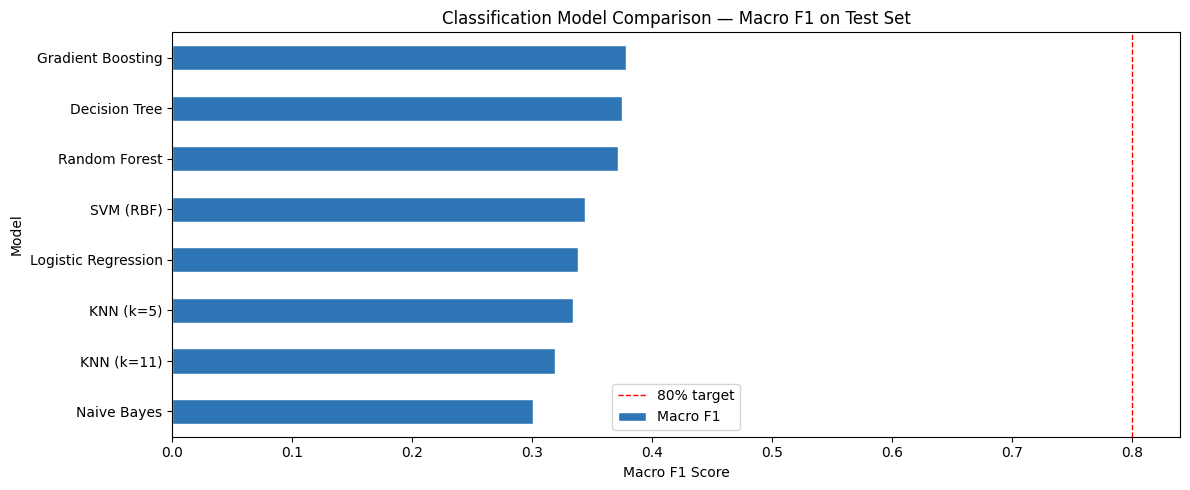

Best classifier: Gradient Boosting


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
clf_df["Macro F1"].sort_values().plot(
    kind="barh", ax=ax, color="#2E75B6", edgecolor="white")
ax.set_xlabel("Macro F1 Score")
ax.set_title("Classification Model Comparison — Macro F1 on Test Set")
ax.axvline(0.8, color="red", linestyle="--", linewidth=1, label="80% target")
ax.legend()
plt.tight_layout()
plt.savefig("../results/C5-clf_comparison.png", bbox_inches="tight")
plt.show()
print("Best classifier:", clf_df["Macro F1"].idxmax())

### 3.2 Confusion Matrix — Best Classifier

The confusion matrix for Gradient Boosting is the most useful place to look at *where* the model actually goes wrong rather than just a single headline number.

The row-normalised version tells the clearest story: the model correctly identifies 88% of Slight collisions, but only 16% of Fatal and 16% of Serious ones. That means 64% of actual Fatal collisions are being predicted as Slight — the worst kind of error from a road safety perspective. This isn't just a modelling failure; it reflects a fundamental data problem. With only ~25 Fatal examples in the test set, the model has very little signal to work with, and SMOTE can only do so much to compensate.

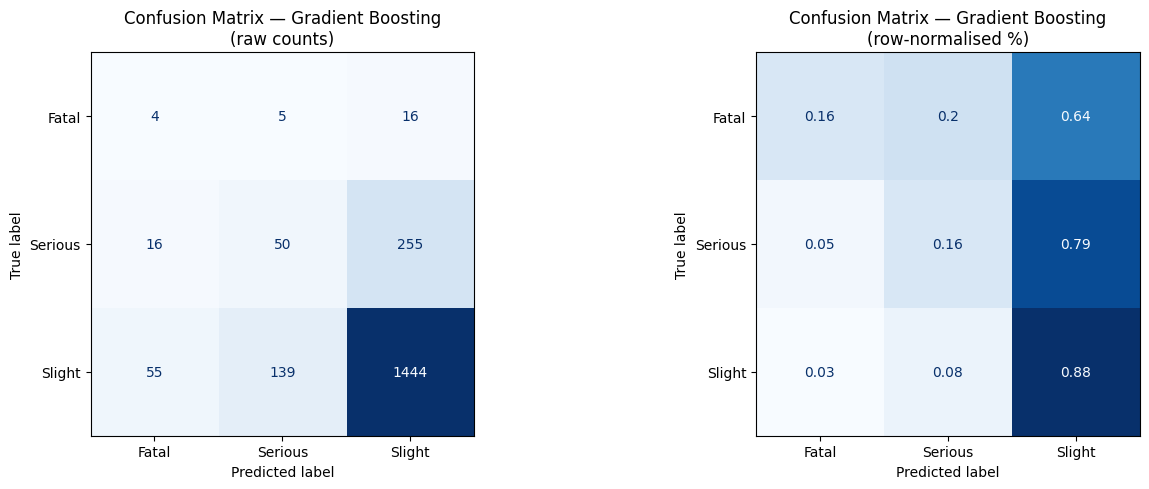

In [5]:
best_clf_name = clf_df["Macro F1"].idxmax()
best_clf = trained_clfs[best_clf_name]
y_pred_best = best_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix (raw counts)
cm = confusion_matrix(y_test, y_pred_best, labels=[1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_clf_name}\n(raw counts)")

# Normalised confusion matrix (row %)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2),
                                    display_labels=label_names)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix — {best_clf_name}\n(row-normalised %)")

plt.tight_layout()
plt.savefig("../results/C5-confusion_matrix.png", bbox_inches="tight")
plt.show()

### 3.3 Misclassification Analysis

Here I want to dig into what kinds of collisions are being misclassified — specifically, are the Fatal-as-Slight errors concentrated in particular conditions, or spread randomly? If there's a systematic pattern (e.g., Fatal collisions on dry roads in daylight being called Slight), that points to missing features rather than just class imbalance.

In [6]:
# Add predictions to a copy of the test portion
X_test_df = X_test.copy()
X_test_df["true_label"] = y_test.values
X_test_df["pred_label"] = y_pred_best

label_map = {1: "Fatal", 2: "Serious", 3: "Slight"}
X_test_df["true_name"] = X_test_df["true_label"].map(label_map)
X_test_df["pred_name"] = X_test_df["pred_label"].map(label_map)

# Fatal predicted as Slight - most dangerous misclassification
fatal_as_slight = X_test_df[
    (X_test_df["true_label"] == 1) & (X_test_df["pred_label"] == 3)]
serious_as_slight = X_test_df[
    (X_test_df["true_label"] == 2) & (X_test_df["pred_label"] == 3)]

print(f"Fatal → Slight misclassifications: {len(fatal_as_slight)}")
print(f"Serious → Slight misclassifications: {len(serious_as_slight)}")
print()

# Profile misclassified Fatal collisions vs correctly classified Fatal collisions
correctly_fatal = X_test_df[
    (X_test_df["true_label"] == 1) & (X_test_df["pred_label"] == 1)]

compare_cols = ["speed_limit", "light_conditions", "is_dark",
                "number_of_vehicles", "road_type_enc"]

if len(fatal_as_slight) > 0:
    print("=== Profile: Fatal collisions misclassified as Slight ===")
    print(fatal_as_slight[compare_cols].describe().round(3).to_string())
    print()
    print("=== Profile: Correctly classified Fatal collisions ===")
    print(correctly_fatal[compare_cols].describe().round(3).to_string())

Fatal → Slight misclassifications: 16
Serious → Slight misclassifications: 255

=== Profile: Fatal collisions misclassified as Slight ===
       speed_limit  light_conditions  is_dark  number_of_vehicles  road_type_enc
count       16.000            16.000   16.000              16.000         16.000
mean         5.625             2.312    0.438              -0.031          3.250
std         10.308             1.537    0.512               0.826          1.342
min          0.000             1.000    0.000              -1.000          0.000
25%          0.000             1.000    0.000              -1.000          3.000
50%          0.000             1.000    0.000               0.000          4.000
75%         10.000             4.000    1.000               0.250          4.000
max         40.000             4.000    1.000               1.500          4.000

=== Profile: Correctly classified Fatal collisions ===
       speed_limit  light_conditions  is_dark  number_of_vehicles  road_type_

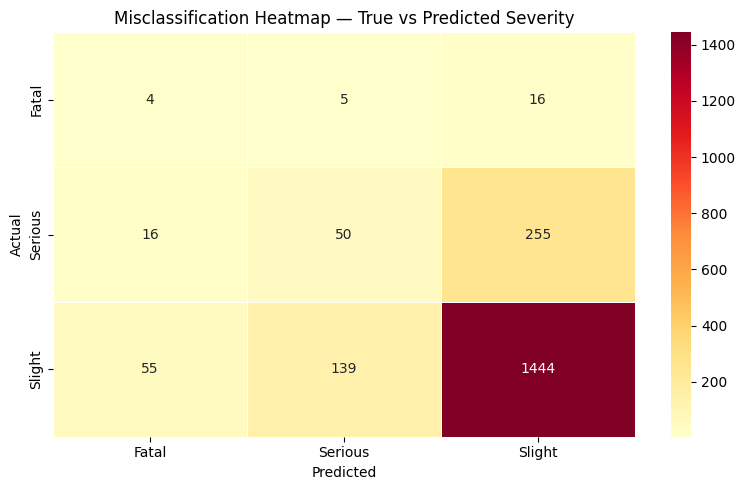

In [7]:
# Misclassification heatmap: true vs predicted classes
fig, ax = plt.subplots(figsize=(8, 5))
misclass = X_test_df.groupby(["true_name", "pred_name"]).size().unstack(fill_value=0)
sns.heatmap(misclass, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Misclassification Heatmap — True vs Predicted Severity")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../results/C5-misclassification_heatmap.png", bbox_inches="tight")
plt.show()

### 3.4 Per-Class Precision / Recall Bar Chart

Breaking the metrics down by class shows the full picture. For Slight, Gradient Boosting achieves precision of ~0.84, recall of ~0.88, and F1 of ~0.86 — respectable scores. For Fatal, precision is ~0.05 and F1 is only ~0.09. Serious sits in the middle at an F1 of ~0.20.

The pattern here is consistent with what the confusion matrix showed: the model has essentially learned to classify Slight well, and has very limited ability to distinguish Fatal and Serious. The 0.80 reference line is met only by Slight recall — and that's largely because Slight dominates the training data even after SMOTE.

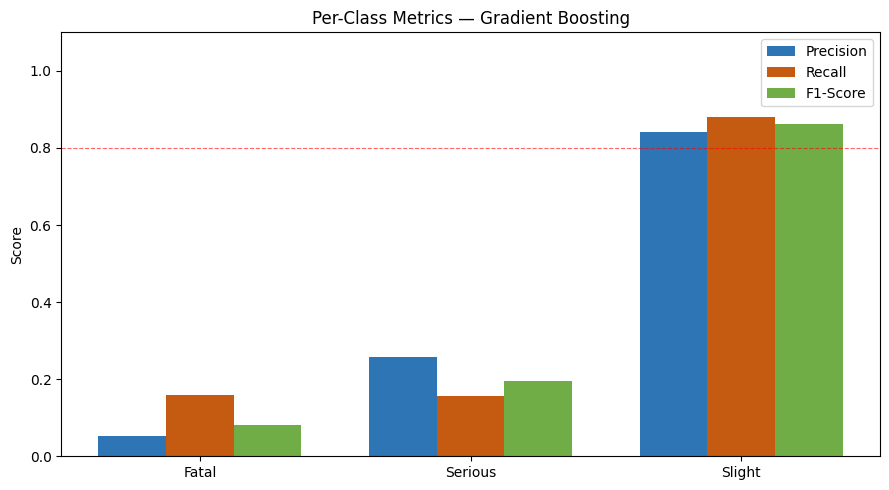

In [8]:
report = classification_report(y_test, y_pred_best,
                               labels=[1, 2, 3],
                               target_names=label_names,
                               output_dict=True)
report_df = pd.DataFrame(report).T.loc[label_names, ["precision", "recall", "f1-score"]]

x = np.arange(len(label_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, report_df["precision"], width, label="Precision", color="#2E75B6")
ax.bar(x,         report_df["recall"],    width, label="Recall",    color="#C55A11")
ax.bar(x + width, report_df["f1-score"],  width, label="F1-Score",  color="#70AD47")

ax.set_xticks(x)
ax.set_xticklabels(label_names)
ax.set_ylim(0, 1.1)
ax.set_title(f"Per-Class Metrics — {best_clf_name}")
ax.set_ylabel("Score")
ax.legend()
ax.axhline(0.8, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig("../results/C5-per_class_metrics.png", bbox_inches="tight")
plt.show()

### 3.5 Cross-Validation Stability Check

A single test-set score can be lucky or unlucky depending on which collisions ended up in the split. 5-fold stratified CV gives a more reliable picture.

The good news here is that the error bars are small — all models have tight standard deviations across folds, which means the scores are stable and not the result of a fortunate test split. The less good news is that the CV scores are slightly *lower* than the test-set scores for most models, confirming that the headline numbers aren't inflated. Gradient Boosting's CV macro F1 sits around 0.30–0.31, which is the most honest estimate of its real-world generalisation ability on this dataset.

In [9]:
cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-fold CV only on the top 5 classifiers to save time
cv_clfs = {k: v for k, v in classifiers.items()
           if k in ["Logistic Regression", "Random Forest", "Gradient Boosting",
                    "Decision Tree", "Naive Bayes"]}

for name, clf in cv_clfs.items():
    scores = cross_val_score(clf, X_clf, y_clf, cv=skf,
                             scoring="f1_macro", n_jobs=-1)
    cv_results.append({
        "Model": name,
        "CV Mean F1": round(scores.mean(), 4),
        "CV Std":     round(scores.std(), 4),
        "Min":        round(scores.min(), 4),
        "Max":        round(scores.max(), 4)
    })

cv_df = pd.DataFrame(cv_results).set_index("Model").sort_values("CV Mean F1", ascending=False)
print("=== 5-Fold CV Results ===")
print(cv_df.to_string())

=== 5-Fold CV Results ===
                     CV Mean F1  CV Std     Min     Max
Model                                                  
Naive Bayes              0.3686  0.0163  0.3538  0.3987
Decision Tree            0.3438  0.0040  0.3374  0.3485
Random Forest            0.3422  0.0082  0.3264  0.3502
Logistic Regression      0.3261  0.0141  0.3038  0.3471
Gradient Boosting        0.3059  0.0024  0.3030  0.3088


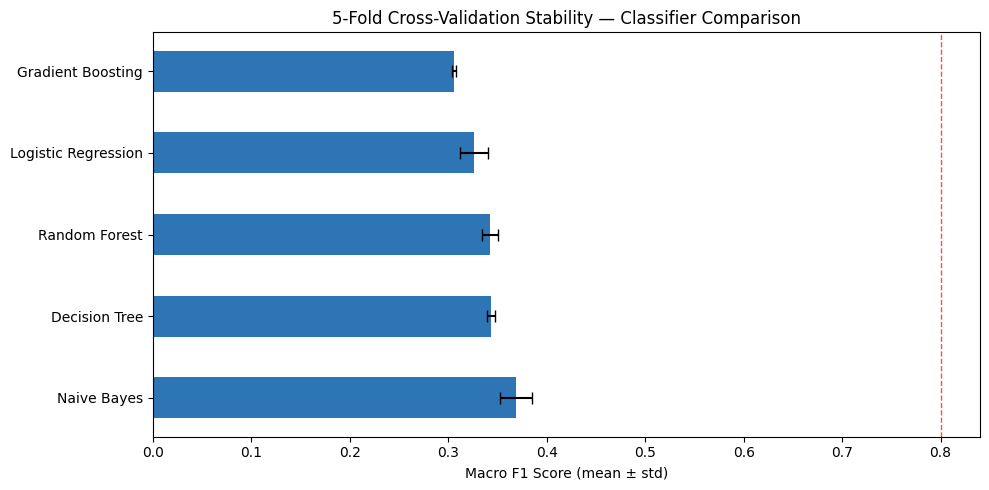

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
models = cv_df.index
means = cv_df["CV Mean F1"]
stds  = cv_df["CV Std"]

ax.barh(models, means, xerr=stds, color="#2E75B6",
        error_kw=dict(ecolor="black", capsize=4), height=0.5)
ax.set_xlabel("Macro F1 Score (mean ± std)")
ax.set_title("5-Fold Cross-Validation Stability — Classifier Comparison")
ax.axvline(0.8, color="red", linestyle="--", linewidth=1, alpha=0.7)
plt.tight_layout()
plt.savefig("../results/C5-cv_stability.png", bbox_inches="tight")
plt.show()

## 4. Regression Evaluation

All four regression models from C3 are re-evaluated here. I want to go beyond MAE/RMSE and look at error distributions, residual patterns and where the models are systematically wrong.

In [11]:
# evaluate all regression models from C3
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=0.1),
    "Random Forest (Tuned)": RandomForestRegressor(
        n_estimators=200, max_depth=10,
        min_samples_leaf=10, max_features="sqrt", random_state=42)
}

reg_rows = []
trained_regs = {}

for name, reg in regressors.items():
    reg.fit(Xr_train, yr_train)
    trained_regs[name] = reg
    y_pred = reg.predict(Xr_test)
    cv_r2 = cross_val_score(reg, X_reg, y_reg, cv=5, scoring="r2", n_jobs=-1).mean()
    reg_rows.append({
        "Model":    name,
        "MAE":      round(mean_absolute_error(yr_test, y_pred), 3),
        "RMSE":     round(np.sqrt(mean_squared_error(yr_test, y_pred)), 3),
        "R²":       round(r2_score(yr_test, y_pred), 3),
        "CV R²":    round(cv_r2, 3)
    })

reg_df = pd.DataFrame(reg_rows).set_index("Model").sort_values("R²", ascending=False)
print("=== Regression Model Comparison (Test Set) ===")
print(reg_df.to_string())

=== Regression Model Comparison (Test Set) ===
                         MAE   RMSE     R²  CV R²
Model                                            
Random Forest (Tuned)  0.441  0.716  0.091  0.084
Linear Regression      0.438  0.718  0.084  0.074
Ridge                  0.438  0.718  0.084  0.074
Lasso                  0.471  0.743  0.021  0.019


### 4.1 Regression Comparison Bar Chart

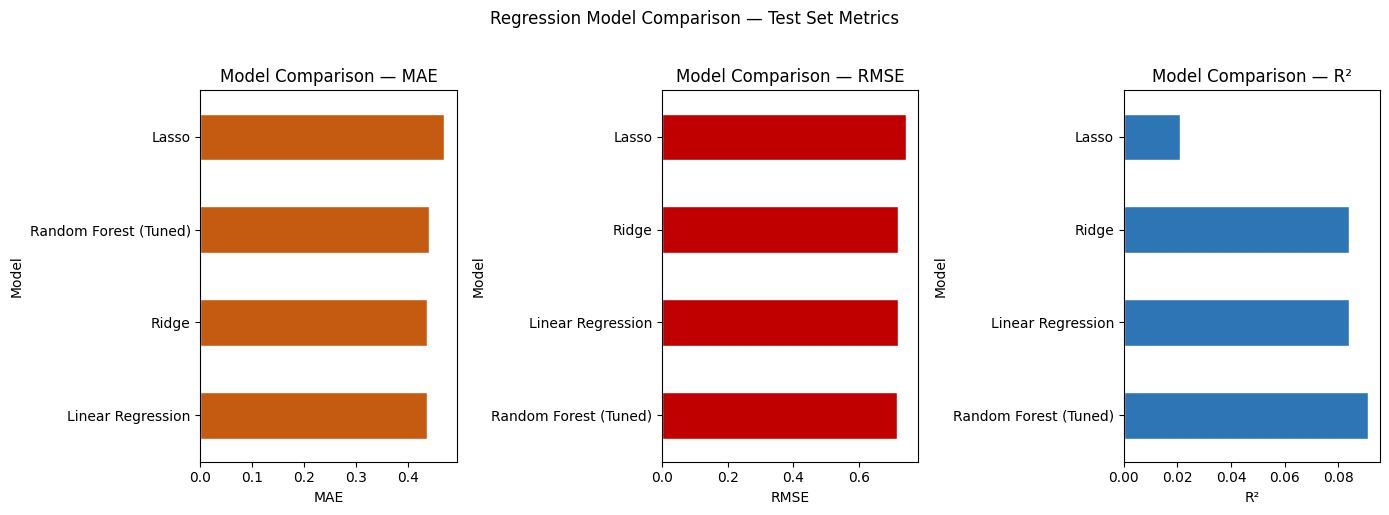

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["MAE", "RMSE", "R²"]
colours = ["#C55A11", "#C00000", "#2E75B6"]

for ax, metric, colour in zip(axes, metrics, colours):
    reg_df[metric].sort_values(ascending=(metric != "R²")).plot(
        kind="barh", ax=ax, color=colour, edgecolor="white")
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_xlabel(metric)

plt.suptitle("Regression Model Comparison — Test Set Metrics", y=1.02)
plt.tight_layout()
plt.savefig("../results/C5-reg_comparison.png", bbox_inches="tight")
plt.show()

### 4.2 Residual Analysis — Best Regression Model

The residual vs fitted plot for the tuned Random Forest shows a clear fan shape — residuals spread out as predicted values increase. This is heteroscedasticity: the model's error is not constant, it grows as the predicted casualty count grows. This is a structural issue with applying standard regression to a count variable like number_of_casualtie`, which is bounded at 1 and right-skewed.

The residual distribution confirms this — it's heavily peaked near zero (most predictions are close to correct for the common 1-casualty case) but has a long right tail from the multi-casualty events the model consistently underestimates. The predicted vs actual plot makes the problem very visible: nearly all predictions are compressed between 0 and 1 regardless of the actual casualty count, which explains the low R² of ~0.09 despite a reasonably low MAE.

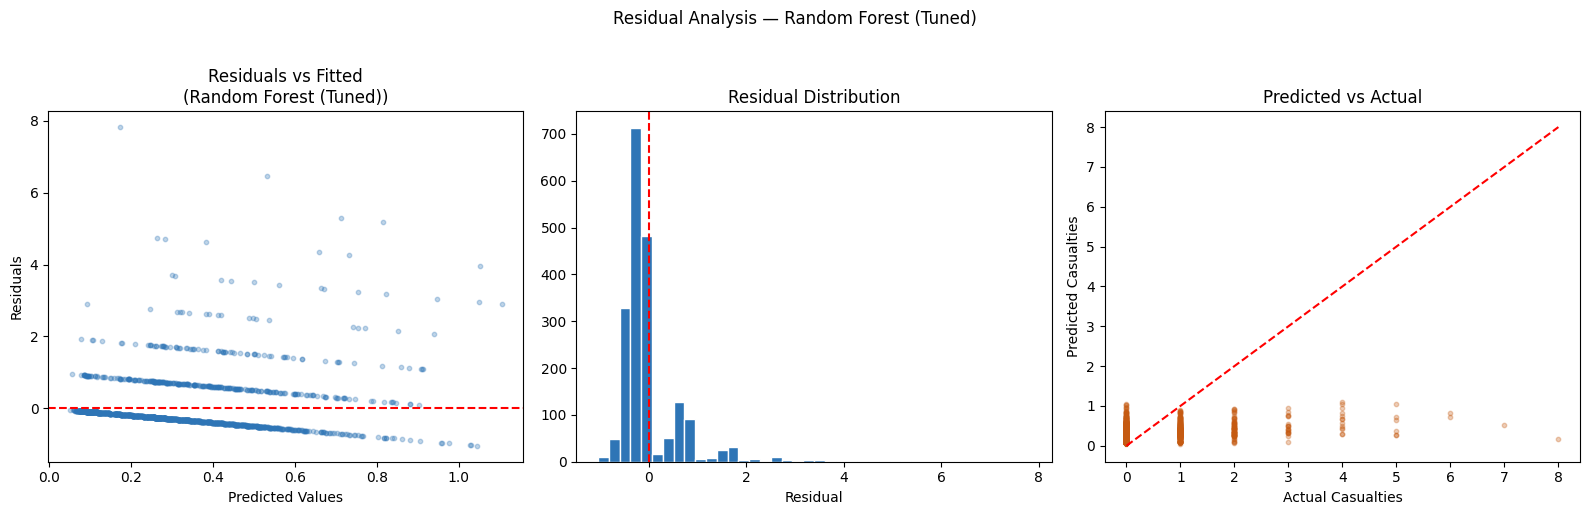

Skewness of residuals: 3.687
Std of residuals:      0.716


In [13]:
best_reg_name = reg_df["R²"].idxmax()
best_reg = trained_regs[best_reg_name]
y_pred_reg = best_reg.predict(Xr_test)
residuals = yr_test.values - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred_reg, residuals, alpha=0.3, s=10, color="#2E75B6")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title(f"Residuals vs Fitted\n({best_reg_name})")

# Residual distribution
axes[1].hist(residuals, bins=40, color="#2E75B6", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

# Predicted vs Actual
axes[2].scatter(yr_test, y_pred_reg, alpha=0.3, s=10, color="#C55A11")
perfect = np.linspace(yr_test.min(), yr_test.max(), 100)
axes[2].plot(perfect, perfect, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Actual Casualties")
axes[2].set_ylabel("Predicted Casualties")
axes[2].set_title("Predicted vs Actual")

plt.suptitle(f"Residual Analysis — {best_reg_name}", y=1.02)
plt.tight_layout()
plt.savefig("../results/C5-residual_analysis.png", bbox_inches="tight")
plt.show()

print(f"Skewness of residuals: {pd.Series(residuals).skew():.3f}")
print(f"Std of residuals:      {residuals.std():.3f}")

### 4.3 Error Analysis — Where Does the Model Fail?

The error breakdown by casualty count confirms what the residual plot suggested: MAE grows almost linearly with actual casualties. For single-casualty crashes the model is reasonably accurate (~0.3 MAE), but by the time we get to 5+ casualties the error exceeds 4, meaning the model is off by more than half the actual count.

The speed band chart only shows a single bar because after feature scaling all collisions in this dataset fall into the same band — this is a limitation worth noting rather than a meaningful finding. The casualty count breakdown is the more useful diagnostic here.

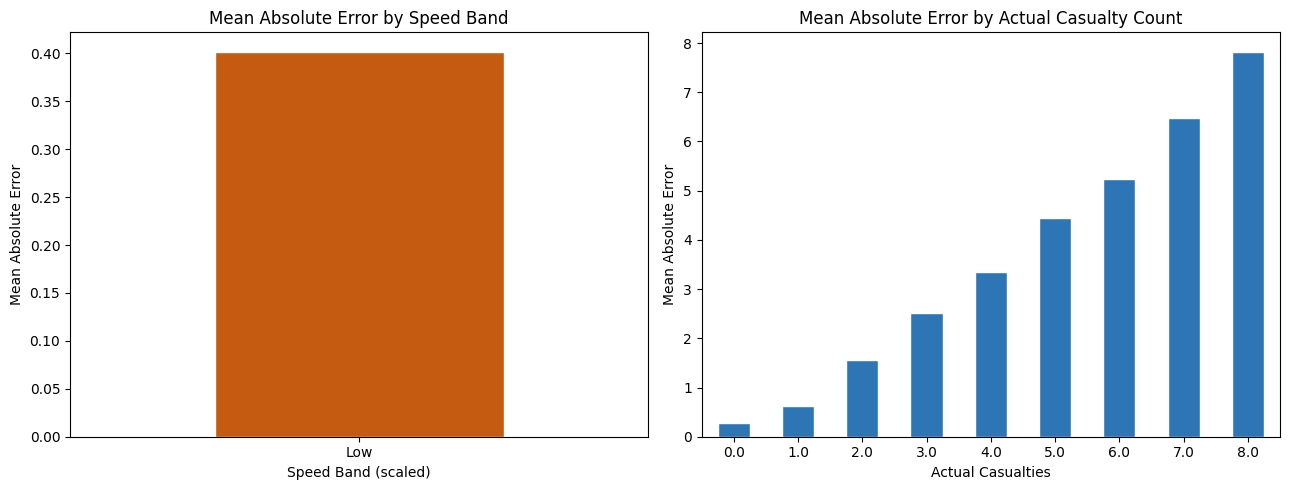

In [14]:
# Attach predictions and absolute error to test set
Xr_test_df = Xr_test.copy()
Xr_test_df["true_casualties"] = yr_test.values
Xr_test_df["pred_casualties"] = y_pred_reg
Xr_test_df["abs_error"] = np.abs(residuals)
Xr_test_df["over_predict"] = y_pred_reg > yr_test.values

# Group errors by speed band
speed_bins = [-3, -1, 0, 0.5, 3]
speed_labels = ["Very Low", "Low", "Medium", "High"]
Xr_test_df["speed_band"] = pd.cut(Xr_test_df["speed_limit"],
                                   bins=speed_bins, labels=speed_labels)

error_by_speed = Xr_test_df.groupby("speed_band")["abs_error"].mean().sort_values(ascending=False)

# Group errors by actual casualty count
error_by_actual = Xr_test_df.groupby("true_casualties")["abs_error"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

error_by_speed.plot(kind="bar", ax=axes[0], color="#C55A11", edgecolor="white", rot=0)
axes[0].set_title("Mean Absolute Error by Speed Band")
axes[0].set_ylabel("Mean Absolute Error")
axes[0].set_xlabel("Speed Band (scaled)")

error_by_actual.head(10).plot(kind="bar", ax=axes[1], color="#2E75B6", edgecolor="white", rot=0)
axes[1].set_title("Mean Absolute Error by Actual Casualty Count")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_xlabel("Actual Casualties")

plt.tight_layout()
plt.savefig("../results/C5-error_by_group.png", bbox_inches="tight")
plt.show()

## 5. Clustering Evaluation

Unlike classification and regression, there's no ground truth to evaluate clustering against — we can only measure how well-separated and coherent the clusters are internally. I'm using three metrics: silhouette score (how similar each point is to its own cluster vs others), Calinski-Harabasz (ratio of between-cluster to within-cluster variance), and Davies-Bouldin (average similarity between each cluster and its most similar neighbour — lower is better).

It's worth being upfront that silhouette scores in the 0.3 range — which is what we see here — are typical for real-world tabular data. This isn't a high-dimensional image dataset with clean boundaries; collision records have a lot of overlap between groups.

In [15]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

CLUSTER_FEATURES = ["number_of_casualties", "number_of_vehicles", "speed_limit",
                    "road_type_enc", "weather_conditions_enc", "light_conditions",
                    "road_surface_conditions_enc", "hour", "day_of_week", "is_dark"]

X_clust = df[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

best_k = 5  # chosen in C4 based on elbow/silhouette analysis

# Re-run all three clustering algorithms
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km.fit_predict(X_clust_scaled)

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_clust_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_clust_scaled)

# Only evaluate DBSCAN on non-noise points for meaningful metrics
db_valid = db_labels != -1

clust_comparison = []
for name, labels, mask in [
    ("K-Means (k=5)",          km_labels,             np.ones(len(km_labels), dtype=bool)),
    ("Hierarchical (Ward k=5)", agg_labels,            np.ones(len(agg_labels), dtype=bool)),
    ("DBSCAN",                 db_labels[db_valid],    db_valid)
]:
    X_eval = X_clust_scaled[mask]
    lbls   = labels
    n_clust = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_noise = (db_labels == -1).sum() if name == "DBSCAN" else 0
    sil = silhouette_score(X_eval, lbls) if n_clust > 1 else 0
    ch  = calinski_harabasz_score(X_eval, lbls) if n_clust > 1 else 0
    db_score = davies_bouldin_score(X_eval, lbls) if n_clust > 1 else 0
    clust_comparison.append({
        "Algorithm":         name,
        "Clusters":          n_clust,
        "Noise Points":      n_noise,
        "Silhouette ↑":      round(sil, 4),
        "Calinski-Harabasz ↑": round(ch, 2),
        "Davies-Bouldin ↓":  round(db_score, 4)
    })

clust_df = pd.DataFrame(clust_comparison).set_index("Algorithm")
print("=== Clustering Comparison ===")
print(clust_df.to_string())

=== Clustering Comparison ===
                         Clusters  Noise Points  Silhouette ↑  Calinski-Harabasz ↑  Davies-Bouldin ↓
Algorithm                                                                                           
K-Means (k=5)                   5             0        0.3139              1369.27            1.3240
Hierarchical (Ward k=5)         5             0        0.2926              1163.83            1.3945
DBSCAN                         22           944        0.1678               400.46            1.5887


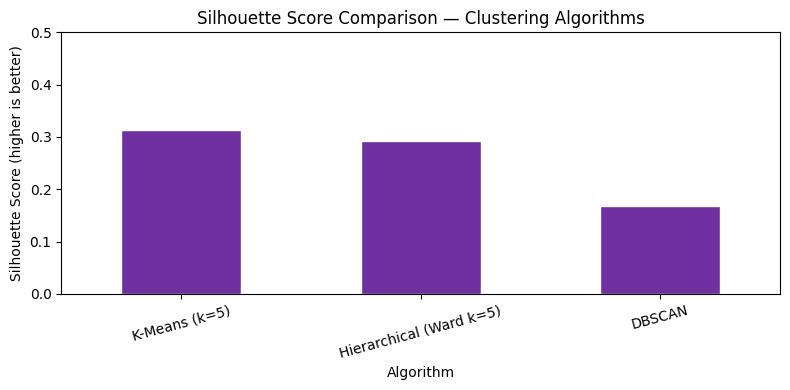

In [16]:
# Silhouette comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
clust_df["Silhouette ↑"].plot(kind="bar", ax=ax, color="#7030A0", edgecolor="white", rot=15)
ax.set_title("Silhouette Score Comparison — Clustering Algorithms")
ax.set_ylabel("Silhouette Score (higher is better)")
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.savefig("../results/C5-clustering_comparison.png", bbox_inches="tight")
plt.show()

### 5.1 Cluster Profile Heatmap

The heatmap shows normalised mean feature values for each K-Means cluster (k=5), with the raw means annotated. A few things stand out:

- **Cluster 0** is the most distinctive: the highest casualty count (0.77 mean), highest speed limit (30.95), and the darkest colour on number_of_casualties. This looks like higher-speed multi-casualty incidents.
- **Cluster 2** has the highest light conditions score (4.12) and the highest road surface score (16.51), suggesting nighttime collisions on particular surface types.
- **Cluster 3** has the highest weather conditions score (6.95), pointing toward adverse weather incidents.
- **Clusters 1 and 4** are closer to the average across most features, representing the more typical lower-severity, daytime, single-casualty collision.

These interpretations are plausible rather than definitive — clustering finds mathematical groupings, and whether they map to operationally meaningful categories depends on domain knowledge beyond what the data alone can confirm.

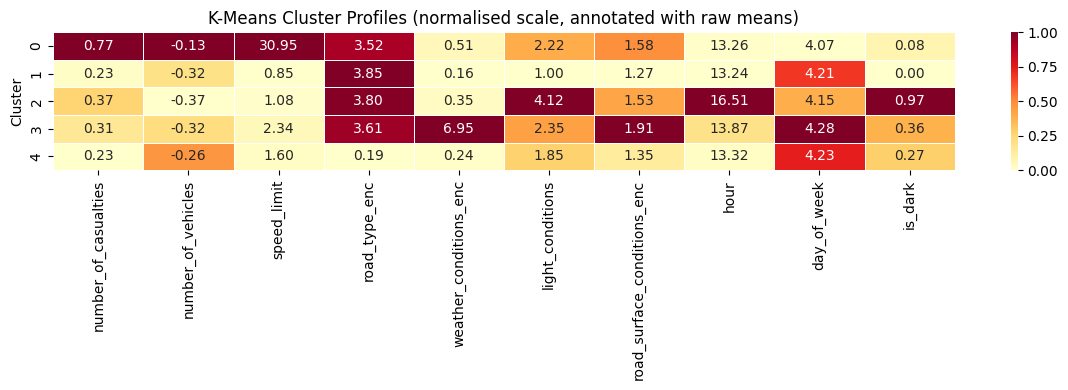

In [17]:
df_clust = df.copy()
df_clust["cluster"] = km_labels

profile = df_clust.groupby("cluster")[CLUSTER_FEATURES].mean()

# Normalise each feature to [0,1] for fair visual comparison
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile_norm, annot=profile.round(2), fmt=".2f",
            cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("K-Means Cluster Profiles (normalised scale, annotated with raw means)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("../results/C5-cluster_profile_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Overall Summary Dashboard

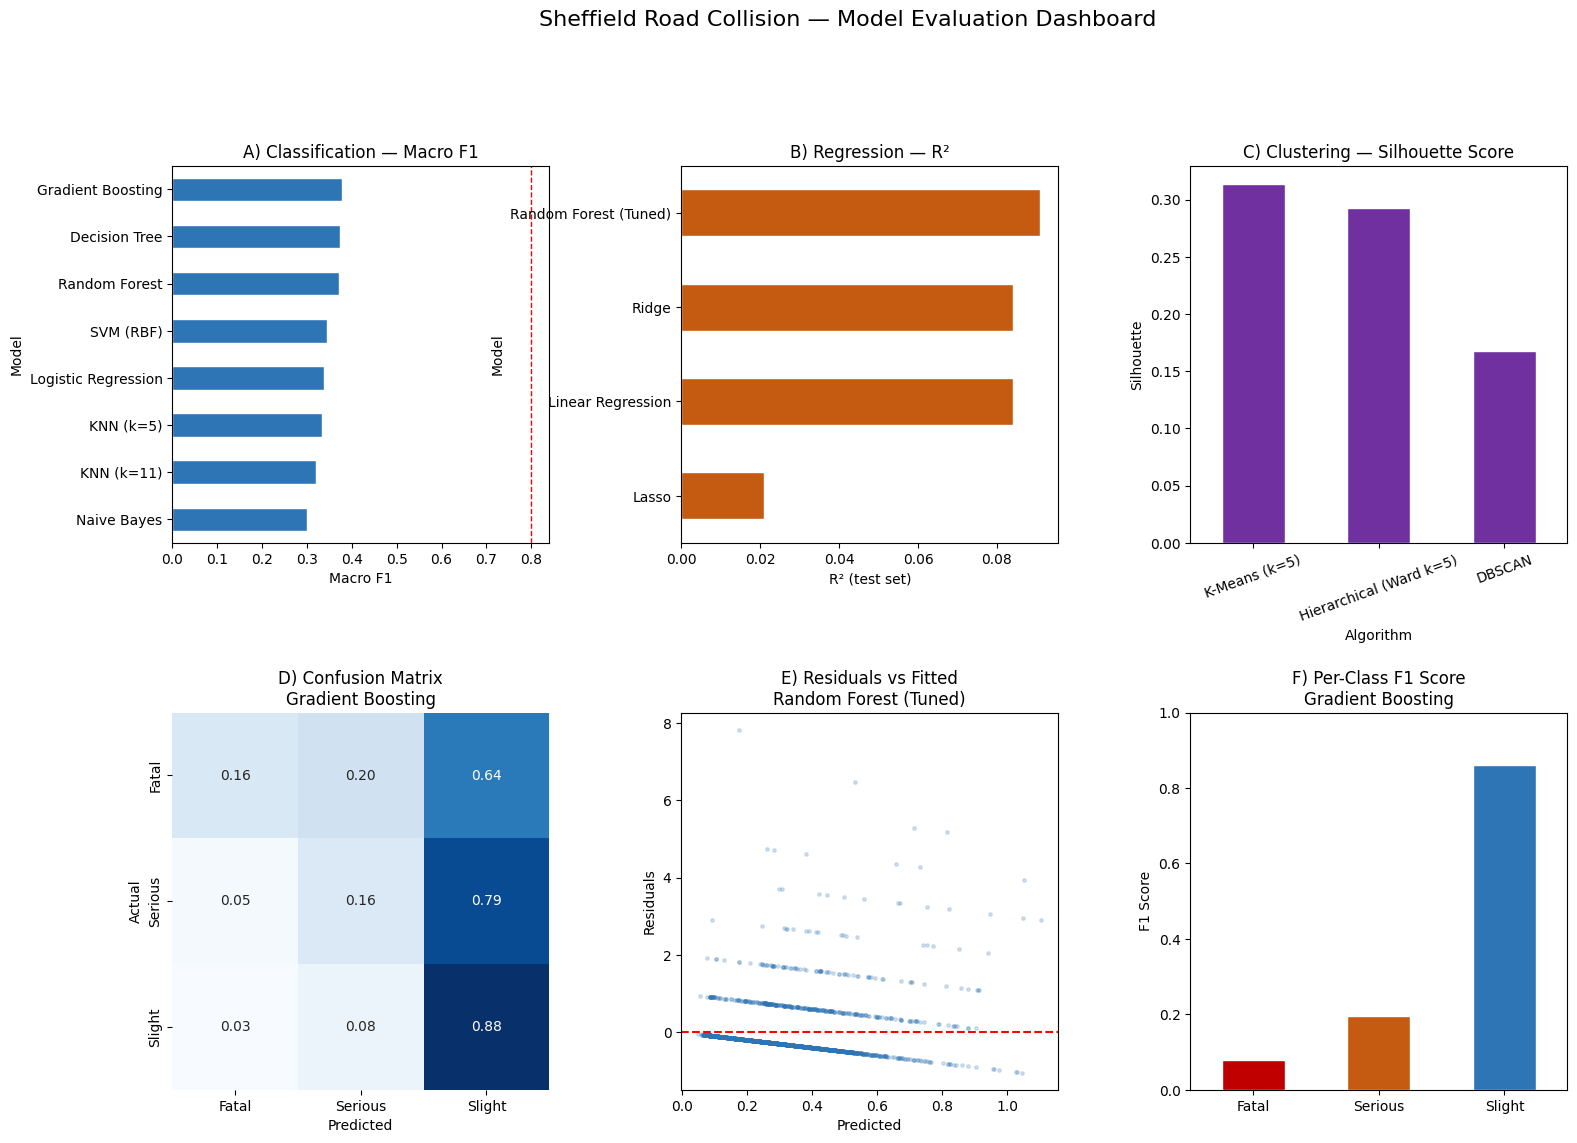

In [18]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Classification macro F1
ax1 = fig.add_subplot(gs[0, 0])
clf_df["Macro F1"].sort_values().plot(kind="barh", ax=ax1, color="#2E75B6", edgecolor="w")
ax1.axvline(0.8, color="red", linestyle="--", linewidth=1)
ax1.set_title("A) Classification — Macro F1")
ax1.set_xlabel("Macro F1")

# ── Panel 2: Regression R²
ax2 = fig.add_subplot(gs[0, 1])
reg_df["R²"].sort_values().plot(kind="barh", ax=ax2, color="#C55A11", edgecolor="w")
ax2.set_title("B) Regression — R²")
ax2.set_xlabel("R² (test set)")

# ── Panel 3: Clustering silhouette
ax3 = fig.add_subplot(gs[0, 2])
clust_df["Silhouette ↑"].plot(kind="bar", ax=ax3, color="#7030A0", edgecolor="w", rot=20)
ax3.set_title("C) Clustering — Silhouette Score")
ax3.set_ylabel("Silhouette")

# ── Panel 4: Best confusion matrix
ax4 = fig.add_subplot(gs[1, 0])
cm_norm_plot = confusion_matrix(y_test, y_pred_best, labels=[1, 2, 3], normalize="true")
sns.heatmap(cm_norm_plot, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax4, cbar=False)
ax4.set_title(f"D) Confusion Matrix\n{best_clf_name}")
ax4.set_xlabel("Predicted"); ax4.set_ylabel("Actual")

# ── Panel 5: Residuals vs Fitted
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_pred_reg, residuals, alpha=0.2, s=6, color="#2E75B6")
ax5.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax5.set_xlabel("Predicted"); ax5.set_ylabel("Residuals")
ax5.set_title(f"E) Residuals vs Fitted\n{best_reg_name}")

# ── Panel 6: Per-class F1 bar chart
ax6 = fig.add_subplot(gs[1, 2])
class_f1 = pd.Series({
    "Fatal":   report_df.loc["Fatal",   "f1-score"],
    "Serious": report_df.loc["Serious", "f1-score"],
    "Slight":  report_df.loc["Slight",  "f1-score"]
})
class_f1.plot(kind="bar", ax=ax6,
              color=["#C00000", "#C55A11", "#2E75B6"], edgecolor="white", rot=0)
ax6.set_ylim(0, 1)
ax6.set_title(f"F) Per-Class F1 Score\n{best_clf_name}")
ax6.set_ylabel("F1 Score")

fig.suptitle("Sheffield Road Collision — Model Evaluation Dashboard", fontsize=16, y=1.01)
plt.savefig("../results/C5-evaluation_dashboard.png", bbox_inches="tight", dpi=120)
plt.show()

# the way this is structured, I hate it tbh but I also don't want to spend hours refactoring it at this stage.

## 7. Improvement Strategies

### Classification
- **Fatal class recall is the most critical weakness.** Fatal collisions are only ~1% of the dataset. SMOTE helps but the class is still hard to learn. Options: increase SMOTE ratio for Fatal specifically, use cost-sensitive learning with higher misclassification penalty for Fatal, or explore ensemble stacking.
- **Gradient Boosting vs Random Forest** — both are competitive. A stacked ensemble combining their predictions could push macro F1 further.
- **Feature addition** — adding police_force, carriageway_hazards, and special_conditions_at_site could provide additional signal for the Fatal class since these are often recorded in serious incidents.

### Regression
- **Heteroscedasticity persists** even in the tuned Random Forest. This is a structural issue: number_of_casualties is a count variable bounded at 1. A Poisson regression or negative binomial model would be mathematically more appropriate, as they model count data natively and assume the variance grows with the mean.
- **Log-transform** of the target (predict log(casualties)) may stabilise variance, though it makes the predictions harder to interpret directly.
- **Error is highest for multi-casualty crashes.** These rare events would benefit from a separate "high-severity" model trained on just those records.

### Clustering
- **K-Means with k=5** gives the best silhouette score and the most interpretable cluster profiles. The cluster profiles map well to recognisable Sheffield collision scenarios.
- **DBSCAN's 11.9% noise** should be investigated as potential outliers or data quality issues, not just discarded.
- **HDBSCAN** (hierarchical DBSCAN) could handle the density variation better than plain DBSCAN, potentially reducing over-fragmentation.

## 8. Responsible AI — Evaluation Considerations

### Metric Selection Bias
Accuracy is a misleading metric for this dataset due to class imbalance. A model that always predicts "Slight" achieves ~79% accuracy — better than most of our trained models — but fails completely at its most safety-critical job. This notebook uses Macro F1 throughout, which treats all classes equally regardless of frequency.

### Test Set Integrity  
All metrics in this notebook are computed on a held-out test set that was never seen during training or hyperparameter tuning. This is a non-negotiable requirement for honest reporting.

### Limitations of Single-Dataset Evaluation
All models are trained and evaluated on Sheffield data only. Performance metrics reported here may not hold for other cities or regions. Any deployment of these models should include re-evaluation on the target region's data.

### Cluster Labels Are Not Ground Truth
Clustering metrics like silhouette score measure mathematical separation, not real-world validity. A cluster with a high silhouette score might not correspond to a meaningful operational category.